# **Introduction of Python and Machine Learning in Phytopathology​​​​​**

# **Case Study 2: Hyperspectral Band Selection for Peanut Stem Rot Detection**

> Xing Wei



## ***Let's get started!***





In [1]:
# clone the Github respoitory on colab
!git clone https://github.com/XingWei19/HyperspecFeatureSelection.git

Cloning into 'HyperspecFeatureSelection'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 45 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 375.64 KiB | 8.35 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [2]:
# check the current work directory
!pwd

/content


In [3]:
# set the working directory
%cd /content/HyperspecFeatureSelection/scripts

/content/HyperspecFeatureSelection/scripts


## **3. Visualization of hyperspectral profiles**

### **3.1 Load the libraries and data**

In [4]:
# load libraries
import numpy as np
import pandas as pd # pandas dataframe
from pandas import read_csv # pandas read csv file
import matplotlib as mpl # plotting figures
import matplotlib.pyplot as plt # plotting figures

In [5]:
# load the dataset - all five classes
#df_all = pd.read_csv('https://raw.githubusercontent.com/XingWei19/HyperspecFeatureSelection/main/inputs/PSR_GH2019_All_int.csv') # load the data directly from github respoitory
df_all = pd.read_csv('/content/HyperspecFeatureSelection/inputs/PSR_GH2019_All_int.csv') # load the data from Colab
# check a subset of data
df_all # In first column of Type: 0 = Healthy; 1 = Presymptomatic; 2 = Lesion_only; 3 = Mild; 4 = Severe

,Type,242.36412,246.95195,251.535172,256.113861,260.687927,265.257385,269.822296,274.382599,278.938293,...,865.050293,868.911255,872.766907,876.617249,880.462219,884.301941,888.13623,891.965271,895.788879,899.225586
0,0,4.379033,4.243781,4.292790,3.746052,3.604976,3.438778,3.442950,3.641581,3.808830,...,84.648964,82.041755,77.425155,75.336659,70.920917,68.044431,70.480797,72.866164,69.854774,71.663773
1,0,3.914614,4.113802,4.318144,3.975428,3.782629,3.754157,3.636937,3.534895,3.209262,...,65.342803,67.257730,65.370617,64.981325,65.311168,67.793237,67.859917,65.166605,65.482514,65.194357
2,0,5.306052,4.781971,4.581165,4.219214,4.196653,4.092795,4.032428,3.800115,3.811554,...,67.122981,64.159309,63.343938,63.127599,66.559265,68.382680,67.940824,65.554937,66.720411,66.909241
3,0,4.290927,4.124496,3.848570,3.356648,3.572660,3.643015,3.423580,3.408087,3.453459,...,71.905829,71.489346,71.082525,71.447937,70.242123,68.524612,69.717407,70.993827,69.043014,68.337850
4,0,4.456511,4.551076,4.495815,4.410871,4.241086,4.228564,4.082194,3.960146,3.937836,...,63.263025,61.357398,62.194651,64.269729,66.334745,67.935672,65.566806,64.018784,65.861331,64.999612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,4,26.888117,26.235286,24.841905,23.569275,22.589815,21.832836,21.348409,20.768160,20.183119,...,61.478538,63.840179,64.293504,64.418756,69.468449,72.303531,70.365839,69.205761,70.984684,69.454792
395,4,8.337610,7.341870,7.022304,6.075024,5.920163,5.570197,5.176222,4.888684,4.750132,...,71.924023,70.620809,71.321564,74.638941,74.785750,74.874521,74.804362,72.341264,71.763745,74.288306
396,4,7.400053,6.902545,6.304267,5.774528,5.527927,5.333477,5.115362,5.036099,4.721626,...,72.429905,72.315737,70.442269,71.199500,73.380480,74.557977,73.368826,71.779893,72.554771,73.865698
397,4,8.753005,7.502058,6.831674,6.445256,6.176069,5.741142,5.489570,5.206589,5.052578,...,72.783323,72.090108,71.978702,73.046450,73.798040,74.435981,74.877110,75.686789,75.308698,74.569979


In [6]:
# check the number of classes in the dataset
trtlist = list(df_all.Type.unique()) # Type: 0 = Healthy; 1 = Presymptomatic; 2 = Lesion_only; 3 = Mild; 4 = Severe
trtlist

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

In [7]:
# select a subset of data for two-class classification
df_hs = df_all[(df_all["Type"] == 0) | (df_all["Type"] == 4)]
df_hs

,Type,242.36412,246.95195,251.535172,256.113861,260.687927,265.257385,269.822296,274.382599,278.938293,...,865.050293,868.911255,872.766907,876.617249,880.462219,884.301941,888.13623,891.965271,895.788879,899.225586
0,0,4.379033,4.243781,4.292790,3.746052,3.604976,3.438778,3.442950,3.641581,3.808830,...,84.648964,82.041755,77.425155,75.336659,70.920917,68.044431,70.480797,72.866164,69.854774,71.663773
1,0,3.914614,4.113802,4.318144,3.975428,3.782629,3.754157,3.636937,3.534895,3.209262,...,65.342803,67.257730,65.370617,64.981325,65.311168,67.793237,67.859917,65.166605,65.482514,65.194357
2,0,5.306052,4.781971,4.581165,4.219214,4.196653,4.092795,4.032428,3.800115,3.811554,...,67.122981,64.159309,63.343938,63.127599,66.559265,68.382680,67.940824,65.554937,66.720411,66.909241
3,0,4.290927,4.124496,3.848570,3.356648,3.572660,3.643015,3.423580,3.408087,3.453459,...,71.905829,71.489346,71.082525,71.447937,70.242123,68.524612,69.717407,70.993827,69.043014,68.337850
4,0,4.456511,4.551076,4.495815,4.410871,4.241086,4.228564,4.082194,3.960146,3.937836,...,63.263025,61.357398,62.194651,64.269729,66.334745,67.935672,65.566806,64.018784,65.861331,64.999612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,4,26.888117,26.235286,24.841905,23.569275,22.589815,21.832836,21.348409,20.768160,20.183119,...,61.478538,63.840179,64.293504,64.418756,69.468449,72.303531,70.365839,69.205761,70.984684,69.454792
395,4,8.337610,7.341870,7.022304,6.075024,5.920163,5.570197,5.176222,4.888684,4.750132,...,71.924023,70.620809,71.321564,74.638941,74.785750,74.874521,74.804362,72.341264,71.763745,74.288306
396,4,7.400053,6.902545,6.304267,5.774528,5.527927,5.333477,5.115362,5.036099,4.721626,...,72.429905,72.315737,70.442269,71.199500,73.380480,74.557977,73.368826,71.779893,72.554771,73.865698
397,4,8.753005,7.502058,6.831674,6.445256,6.176069,5.741142,5.489570,5.206589,5.052578,...,72.783323,72.090108,71.978702,73.046450,73.798040,74.435981,74.877110,75.686789,75.308698,74.569979


### **3.2 Data selection and quality check**





In [8]:
# select the dataset to work with
dataset = df_hs # demo - two class classification
#dataset = df_all # practice - five class classification

In [9]:
# split into input (X) and output (y) variables
wl_all = dataset.columns[1:158]
X = dataset.iloc[:,1:158] # input spectral features
y = dataset.iloc[:,0] # labels including 0 = Healthy; 1 = Presymptomatic; 2 = Lesion_only; 3 = Mild; 4 = Severe
print ("shape of dataset:", X.shape, y.shape)

shape of dataset: (175, 157) (175,)


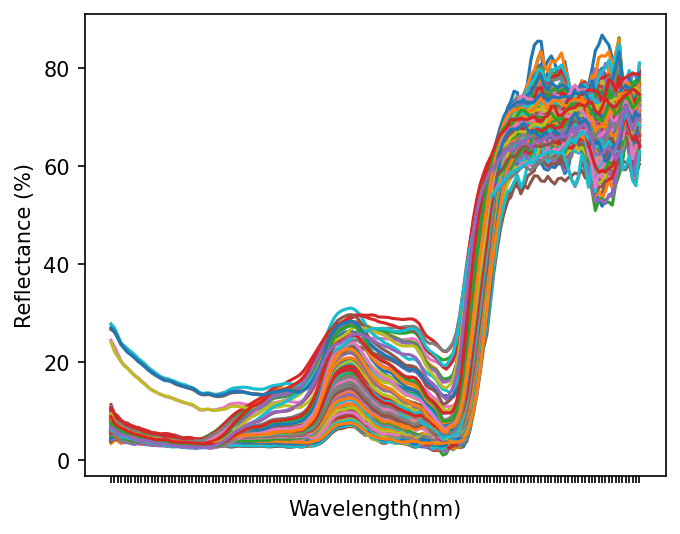

In [10]:
# plot the original spectrum profiles
fig,ax = plt.subplots(figsize=(5,4), dpi=150)
ax.plot(X.T)
ax.set_ylabel('Reflectance (%)')
ax.set_xlabel('Wavelength(nm)')

# Turn off tick labels
#ax.set_yticklabels([])
ax.set_xticklabels([])

plt.show()

### **3.3 Plot averaged hyperspectral profiles**

In [11]:
# rebuild the dataframe to visualize hyperspectral profiles
df = pd.DataFrame(X)
# set wavelength column
df_wave = pd.DataFrame(wl_all)
df_wave.columns = ['Wavelength']
df.columns = df_wave['Wavelength']
# set label column
df['Label'] = y
# create a list of categories
df

Wavelength,242.36412,246.95195,251.535172,256.113861,260.687927,265.257385,269.822296,274.382599,278.938293,283.489349,...,868.911255,872.766907,876.617249,880.462219,884.301941,888.13623,891.965271,895.788879,899.225586,Label
0,4.379033,4.243781,4.292790,3.746052,3.604976,3.438778,3.442950,3.641581,3.808830,3.499139,...,82.041755,77.425155,75.336659,70.920917,68.044431,70.480797,72.866164,69.854774,71.663773,0
1,3.914614,4.113802,4.318144,3.975428,3.782629,3.754157,3.636937,3.534895,3.209262,3.096529,...,67.257730,65.370617,64.981325,65.311168,67.793237,67.859917,65.166605,65.482514,65.194357,0
2,5.306052,4.781971,4.581165,4.219214,4.196653,4.092795,4.032428,3.800115,3.811554,3.607524,...,64.159309,63.343938,63.127599,66.559265,68.382680,67.940824,65.554937,66.720411,66.909241,0
3,4.290927,4.124496,3.848570,3.356648,3.572660,3.643015,3.423580,3.408087,3.453459,3.305094,...,71.489346,71.082525,71.447937,70.242123,68.524612,69.717407,70.993827,69.043014,68.337850,0
4,4.456511,4.551076,4.495815,4.410871,4.241086,4.228564,4.082194,3.960146,3.937836,3.863455,...,61.357398,62.194651,64.269729,66.334745,67.935672,65.566806,64.018784,65.861331,64.999612,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,26.888117,26.235286,24.841905,23.569275,22.589815,21.832836,21.348409,20.768160,20.183119,19.539770,...,63.840179,64.293504,64.418756,69.468449,72.303531,70.365839,69.205761,70.984684,69.454792,4
395,8.337610,7.341870,7.022304,6.075024,5.920163,5.570197,5.176222,4.888684,4.750132,4.668723,...,70.620809,71.321564,74.638941,74.785750,74.874521,74.804362,72.341264,71.763745,74.288306,4
396,7.400053,6.902545,6.304267,5.774528,5.527927,5.333477,5.115362,5.036099,4.721626,4.375578,...,72.315737,70.442269,71.199500,73.380480,74.557977,73.368826,71.779893,72.554771,73.865698,4
397,8.753005,7.502058,6.831674,6.445256,6.176069,5.741142,5.489570,5.206589,5.052578,4.899567,...,72.090108,71.978702,73.046450,73.798040,74.435981,74.877110,75.686789,75.308698,74.569979,4


In [12]:
# dataframe transformation to match the input data format for plotting
df_melt = df.melt(id_vars='Label', value_name='Reflectance')
df_melt

,Label,Wavelength,Reflectance
0,0,242.36412,4.379033
1,0,242.36412,3.914614
2,0,242.36412,5.306052
3,0,242.36412,4.290927
4,0,242.36412,4.456511
...,...,...,...
27470,4,899.225586,69.454792
27471,4,899.225586,74.288306
27472,4,899.225586,73.865698
27473,4,899.225586,74.569979


In [13]:
# change the data type of each column from object to float for plotting purpose
#df_melt["Label"] = df_melt.Label.astype(float)
df_melt["Wavelength"] = df_melt.Wavelength.astype(float)
df_melt["Reflectance"] = df_melt.Reflectance.astype(float)

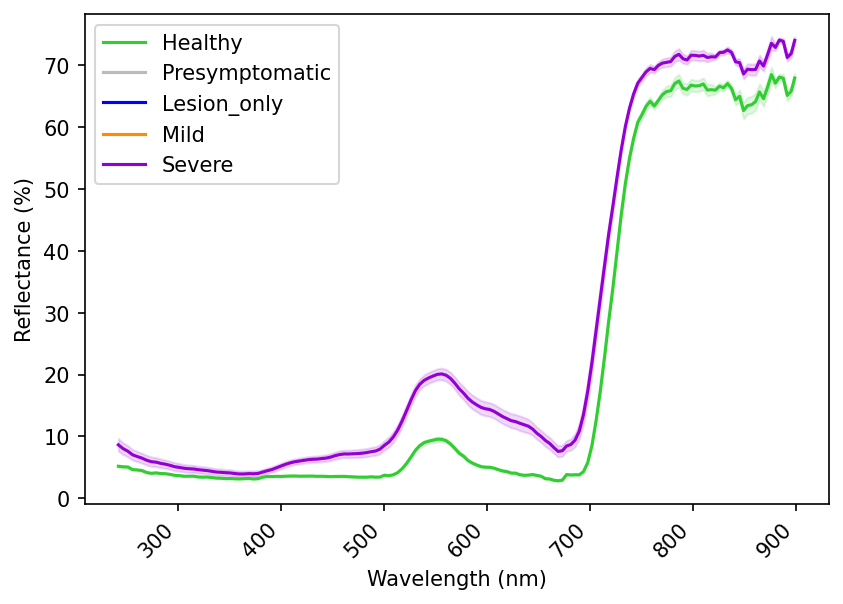

In [14]:
# built a for loop to plot lines with confidence interval
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code

fig, ax = plt.subplots(dpi=150)
for i in range(len (trtlist)):
    df_melt_trt = df_melt[df_melt.Label == trtlist[i]]
    df_grouped = (df_melt_trt[['Wavelength', 'Reflectance']].groupby(['Wavelength']).agg(['mean', 'std', 'count']))
    df_grouped = df_grouped.droplevel(axis=1, level=0).reset_index()
    # Calculate a confidence interval as well.
    df_grouped['ci'] = 1.96 * df_grouped['std'] / np.sqrt(df_grouped['count'])
    df_grouped['ci_lower'] = df_grouped['mean'] - df_grouped['ci']
    df_grouped['ci_upper'] = df_grouped['mean'] + df_grouped['ci']

    x = df_grouped['Wavelength']
    ax.plot(x, df_grouped['mean'], label=labels[i], color=color[i])
    ax.fill_between(x, df_grouped['ci_lower'], df_grouped['ci_upper'], color=color[i], alpha=.15)
    fig.autofmt_xdate(rotation=45)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

## **4. Classical feature reduction method**

### **4.1 Principal components analysis (PCA)**
*  unsupervised, dimensionality reduction method
*  learn about PCA in scikit-learn at [Link](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA)





In [15]:
from sklearn.decomposition import PCA #unsupervised

In [17]:
# create the PCA instance
# X = X.drop(columns="Label")
features = X
label = y
pca = PCA(n_components=2) # let's only consider the first two PCs
pca_results = pca.fit_transform(features) # Fit the model with input and apply the dimensionality reduction on it.
print(pca_results.shape)
pca_scores = pca.explained_variance_ratio_ # variance explained by each component
print('variance explained by the first two PCs: {:.2%}, {:.2%}'.format(*pca_scores))

(175, 2)
variance explained by the first two PCs: 70.49%, 18.55%


In [18]:
# define the colormap mapping 0,1,2,3,4 to different colors
import matplotlib as mpl
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'], name='organs') # hex code

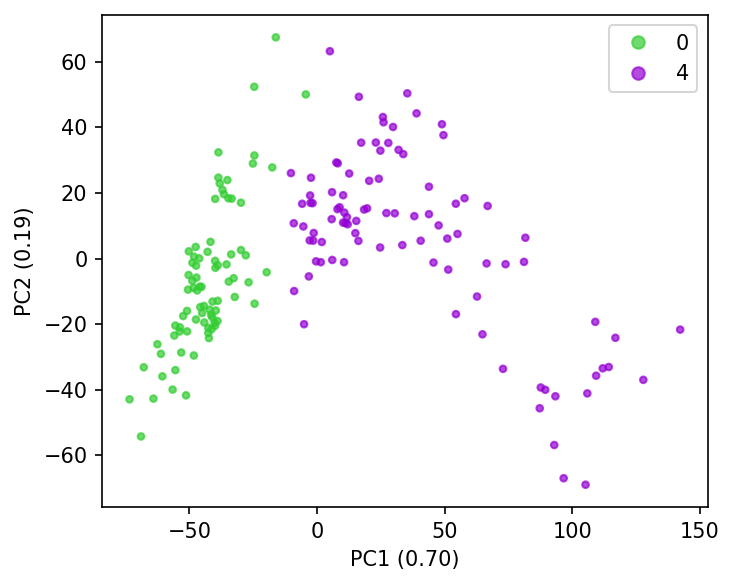

In [19]:
fig, ax = plt.subplots(figsize=(5,4), dpi=150)
s1, s2 = pca_results[:, 0], pca_results[:, 1]
scatter = ax.scatter(s1, s2, c=label, cmap=cmap, s=10, alpha=0.7)

# create the legend
hs, _ = scatter.legend_elements() # handlers of the legend
#labels = ['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe'] # labels of the legend
ax.legend(hs, label.unique())

# add labels
ax.set_xlabel('PC1 (%.2f)'%pca_scores[0])
ax.set_ylabel('PC2 (%.2f)'%pca_scores[1])
plt.tight_layout()
plt.show()



## **> Let's do some practice!**


> Examine data with multiple classes - Section 3.2





## **5. Exploration of feature selection methods in sklearn**



*   To improve model accuracy on very high-dimensional datasets
*   Learn more about feature selection in sklearn at [link](https://scikit-learn.org/stable/modules/feature_selection.html)





In [20]:
# load libraries
from sklearn.feature_selection import SelectKBest # Univariate feature selection
from sklearn.feature_selection import chi2 # Compute chi-squared stats between each non-negative feature and class
from sklearn.feature_selection import RFE # Recursive feature elimination
from sklearn.feature_selection import SelectFromModel # A meta-transformer that can be used alongside any estimator
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier # discriminative and supervised
from sklearn.svm import SVC # discriminative and supervised
from time import time

In [21]:
# get a list of models to evaluate
def get_models():
    models = []
    models.append(('RF', RandomForestClassifier()))
    #models.append(('SVML', SVC(kernel='linear')))
    return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    scores = 100*scores
    return scores

In [22]:
# plot selected wavelengths
def plot_selected_wvs(selected_top_features):
  for i in range(len (trtlist)):
    df_melt_trt = df_melt[df_melt.Label == trtlist[i]]
    df_grouped = (df_melt_trt[['Wavelength', 'Reflectance']].groupby(['Wavelength']).agg(['mean', 'std', 'count']))
    df_grouped = df_grouped.droplevel(axis=1, level=0).reset_index()
    # Calculate a confidence interval as well.
    df_grouped['ci'] = 1.96 * df_grouped['std'] / np.sqrt(df_grouped['count'])
    df_grouped['ci_lower'] = df_grouped['mean'] - df_grouped['ci']
    df_grouped['ci_upper'] = df_grouped['mean'] + df_grouped['ci']

    x = np.array(df_grouped['Wavelength'])
    ax.plot(x, df_grouped['mean'], label=labels[i], color=color[i])
    ax.fill_between(x, df_grouped['ci_lower'], df_grouped['ci_upper'], color=color[i], alpha=.15)
    fig.autofmt_xdate(rotation=45)

  for wv in selected_top_features:
    ax.axvline(x = int(float(wv)), color = 'teal', linestyle ="--")
  return (fig)

In [23]:
# Initial a list of feature seletion methods to evaluate
methods = []
# set the number of features to be selected
top_n_features = 10
# initialize a list to store all the selected top number of features
top_features = []
# set the distance between each selected features
distance = 20
# initialize a list to store all the selected top number of features WITH custom distance
top_features_dist = []

### **5.1 Univariate feature selection - chi2 test**

In [24]:
# load libraries
import numpy as np
from numpy import mean
from numpy import std
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(chi2, k=top_n_features)
#X = X.drop(columns="Label")
fit = bestfeatures.fit(X, y)

feature_names = np.array(wl_all)
print("Features selected by SelectKBest: "
      f"{feature_names[(fit.get_support())]}")

Features selected by SelectKBest: ['581.867798' '586.088501' '590.30426' '594.515015' '598.720825'
 '694.069275' '698.154175' '702.233948' '706.308533' '710.378174']


In [25]:
# build a dataframe including scores for each feature
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

# concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Wavelengths','Score']  #naming the dataframe columns

# sort the featureScores dataframe based on feature weight and ignore the original index
feature_sorted = featureScores.sort_values(by = 'Score', ascending=False, ignore_index=True)
# only save the top n features into the list
df_top_n_features = feature_sorted['Wavelengths'][0:top_n_features]
top_features.append(df_top_n_features.values)

print("Top features ranked by their scores: \n"
      f"{featureScores.nlargest(10,'Score')}")  #print 10 selected features

Top features ranked by their scores: 
    Wavelengths       Score
106  702.233948  500.869282
105  698.154175  487.424268
107  706.308533  456.611799
104  694.069275  402.292744
80   594.515015  391.368839
79    590.30426  390.602712
108  710.378174  390.308522
78   586.088501  388.063030
81   598.720825  387.086863
77   581.867798  384.813929


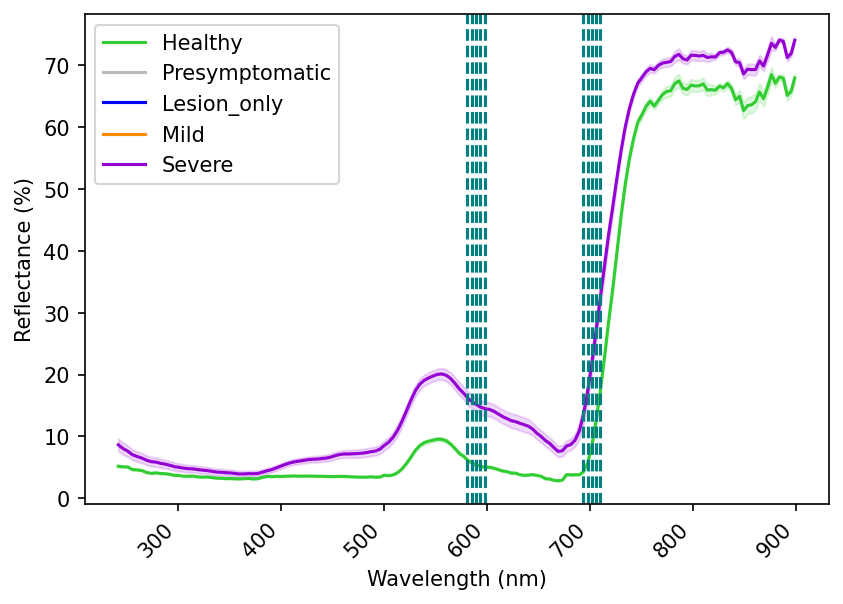

In [26]:
# set the wavelengths to be plotted
selected_top_features = feature_names[(fit.get_support())]

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [27]:
# reduce X to the selected features
X_new = fit.transform(X)
X_new.shape

(175, 10)

In [28]:
# compare the classification accuracy using only top 10 selected wavelengths
models = get_models()
# evaluate the models and store results
results = []
names = []
methods.append ('Chi2')
for name, model in models:
    scores = evaluate_model(model, X_new, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 99.248 (1.917)


In [29]:
#import scripts for hyperspectral band selection - authored by Xing Wei and Marcela A. Johnson
!python hyperspectral_band_selection.py
import hyperspectral_band_selection
from hyperspectral_band_selection import band_select_distance

In [30]:
# reduce X to the selected features WITH custom distance
X_dist = band_select_distance(X, featureScores, distance, top_n_features)
X_dist.shape
# save the top n features WITH custom distance into the list
top_features_dist.append(X_dist.columns)

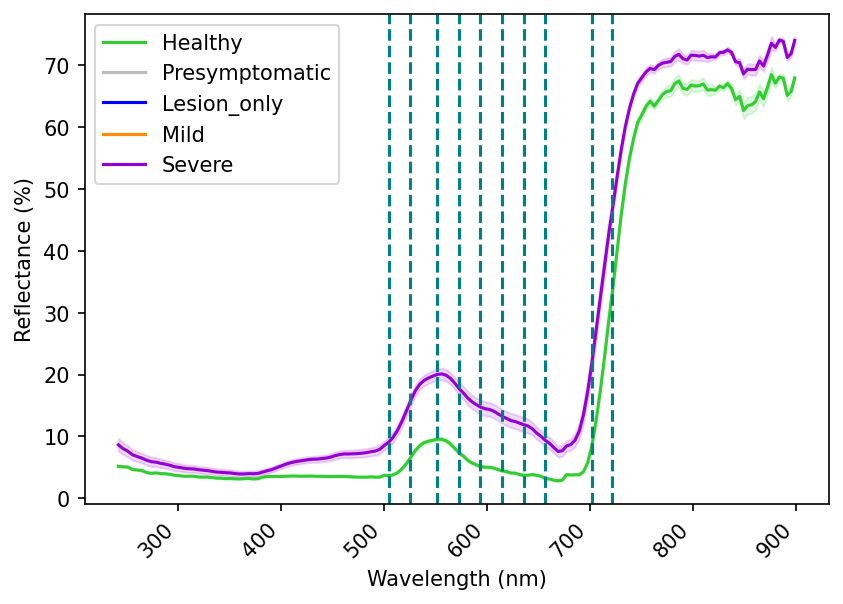

In [31]:
# set the wavelengths to be plotted
selected_top_features = X_dist.columns

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [32]:
# compare the classification accuracy using the distanced top 10 selected wavelengths
models = get_models()
# evaluate the models and store results
results_dist = []
names = []
#methods.append ('Chi2')
for name, model in models:
    scores = evaluate_model(model, X_dist, y)
    results_dist.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)


### **5.2 Feature selection using SelectFromModel**

### **5.2.1 Random forest - feature importance and selection**

In [33]:
# define the model
model = RandomForestClassifier()
feature_names = np.array(wl_all)

# select the features with the SelectFromModel from sklearn.feature_selection
tic = time()
sfm = SelectFromModel(model.fit(X,y), threshold=-np.inf, max_features=top_n_features).fit(X, y)
toc = time()

print("Features selected by SelectFromModel: "
      f"{feature_names[sfm.get_support()]}")
print(f"Done in {toc - tic:.3f}s")

Features selected by SelectFromModel: ['487.766541' '500.737885' '505.052002' '509.361176' '594.515015'
 '602.921631' '615.494019' '623.850769' '632.187378' '640.503967']
Done in 0.346s


In [34]:
# build a dataframe including scores for each feature
dfscores = pd.DataFrame(sfm.estimator_.feature_importances_)
dfcolumns = pd.DataFrame(X.columns)

# concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Wavelengths','Score']  #naming the dataframe columns

# sort the featureScores dataframe based on feature weight and ignore the original index
feature_sorted = featureScores.sort_values(by = 'Score', ascending=False, ignore_index=True)
# only save the top n features into the list
df_top_n_features = feature_sorted['Wavelengths'][0:top_n_features]
top_features.append(df_top_n_features.values)

print("Top features ranked by their scores: \n"
      f"{featureScores.nlargest(10,'Score')}")  #print 10 selected features
print(f"Done in {toc - tic:.3f}s")

Top features ranked by their scores: 
   Wavelengths  Score
80  594.515015   0.06
87  623.850769   0.06
60  509.361176   0.05
89  632.187378   0.05
58  500.737885   0.04
59  505.052002   0.04
82  602.921631   0.04
85  615.494019   0.04
91  640.503967   0.04
55  487.766541   0.03
Done in 0.346s


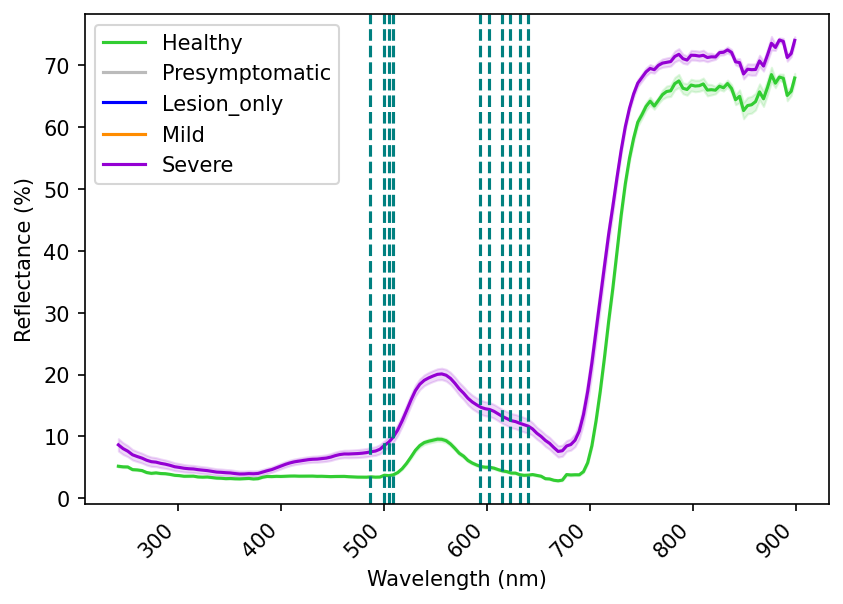

In [35]:
# top 10 selected wavelengths
selected_top_features = feature_names[sfm.get_support()]

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [36]:
# reduce X to the selected features
X_new = sfm.transform(X)
X_new.shape

(175, 10)

In [37]:
# compare the classification accuracy using only selected wavelengths
models = get_models()
methods.append ('SFM_RF')
for name, model in models:
    scores = evaluate_model(model, X_new, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)


In [38]:
#import scripts for hyperspectral band selection
!python hyperspectral_band_selection.py
import hyperspectral_band_selection
from hyperspectral_band_selection import band_select_distance

In [39]:
# reduce X to the selected features WITH custom distance
X_dist = band_select_distance(X, featureScores, distance, top_n_features)
X_dist.shape
# save the top n features WITH custom distance into the list
top_features_dist.append(X_dist.columns)

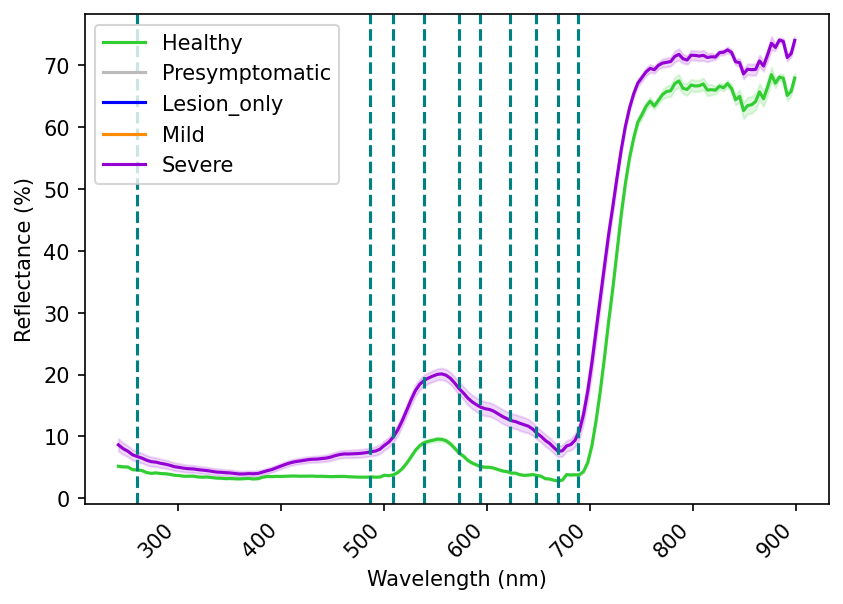

In [40]:
# set the wavelengths to be plotted
selected_top_features = X_dist.columns

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [41]:
# compare the classification accuracy using only selected wavelengths
models = get_models()
#methods.append ('SFM_RF')
for name, model in models:
    scores = evaluate_model(model, X_dist, y)
    results_dist.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)




## **> It is practice time!**


*   Let's practice to run the following section 5.2.2 independently




### **5.2.2 Support vector machine linear**

In [42]:
# feature importance via coefficients
# only apply to SVM with a linear kernel

# define the model
model = SVC(kernel = 'linear')
feature_names = np.array(wl_all)

# select the features with the SelectFromModel from sklearn.feature_selection
tic = time()
sfm = SelectFromModel(model.fit(X,y), threshold=-np.inf, max_features=top_n_features).fit(X, y)
toc = time()

print("Features selected by SelectFromModel: "
      f"{feature_names[sfm.get_support()]}")
print(f"Done in {toc - tic:.3f}s")

Features selected by SelectFromModel: ['689.979309' '694.069275' '698.154175' '830.06311' '837.875061'
 '853.435486' '884.301941' '888.13623' '895.788879' '899.225586']
Done in 0.017s


In [43]:
# build a dataframe including scores for each feature
coefficient = pd.DataFrame(np.abs(sfm.estimator_.coef_)) # use the absolute value of each cofficient
dfscores = pd.DataFrame(coefficient.mean()) # use the average of absolute coefficient as the score for each feature
dfcolumns = pd.DataFrame(X.columns)

# concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Wavelengths','Score']  #naming the dataframe columns

# sort the featureScores dataframe based on feature weight and ignore the original index
feature_sorted = featureScores.sort_values(by = 'Score', ascending=False, ignore_index=True)
# only save the top n features into the list
df_top_n_features = feature_sorted['Wavelengths'][0:top_n_features]
top_features.append(df_top_n_features.values)

print("Top features ranked by their scores: \n"
      f"{featureScores.nlargest(10,'Score')}")  #print 10 selected features
print(f"Done in {toc - tic:.3f}s")

Top features ranked by their scores: 
    Wavelengths     Score
156  899.225586  0.036702
144  853.435486  0.030161
152  884.301941  0.026979
140  837.875061  0.026623
138   830.06311  0.026176
153   888.13623  0.026016
103  689.979309  0.025264
104  694.069275  0.023698
155  895.788879  0.023192
105  698.154175  0.022112
Done in 0.017s


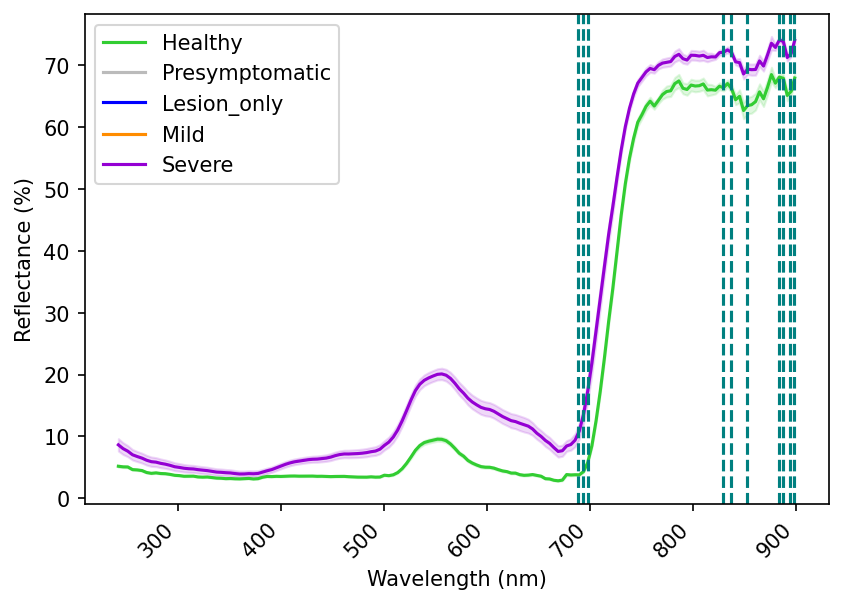

In [44]:
# top 10 selected wavelengths
selected_top_features = feature_names[sfm.get_support()]

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [45]:
# reduce X to the selected features
X_new = sfm.transform(X)
X_new.shape

(175, 10)

In [46]:
# compare the classification accuracy using only selected wavelengths
models = get_models()
methods.append ('SFM_SVML')
for name, model in models:
    scores = evaluate_model(model, X_new, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)


In [47]:
#import scripts for hyperspectral band selection
!python hyperspectral_band_selection.py
import hyperspectral_band_selection
from hyperspectral_band_selection import band_select_distance

In [48]:
# reduce X to the selected features WITH custom distance
X_dist = band_select_distance(X, featureScores, distance, top_n_features)
X_dist.shape
# save the top n features WITH custom distance into the list
top_features_dist.append(X_dist.columns)

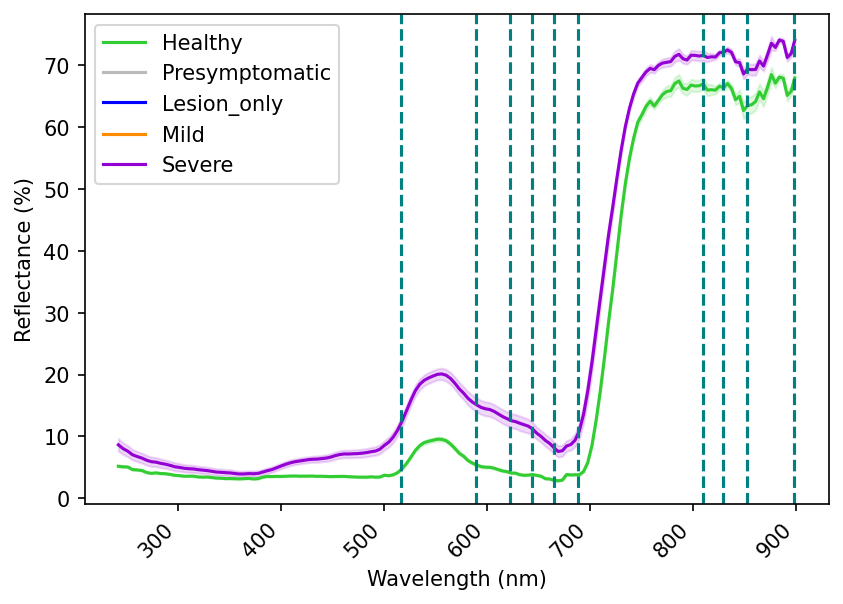

In [49]:
# set the wavelengths to be plotted
selected_top_features = X_dist.columns

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [50]:
# compare the classification accuracy using only selected wavelengths
models = get_models()
#methods.append ('SFM_SVML')
for name, model in models:
    scores = evaluate_model(model, X_dist, y)
    results_dist.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)


### **5.3 Recursive feature elimination (RFE) (Bonus)**

In [52]:
# load libraries
from sklearn.feature_selection import RFE

In [51]:
# define RFE and select an estimator
estimator = RandomForestClassifier()
#estimator = SVC(kernel = 'linear')
rfe = RFE(estimator, n_features_to_select=top_n_features)

# fit RFE
tic = time()
rfe_fit = rfe.fit(X, y)
toc = time()

# build a dataframe including ranking for each feature
dfranking = pd.DataFrame(rfe_fit.ranking_)
dfcolumns = pd.DataFrame(X.columns)

# concat two dataframes for better visualization
feature_ranking = pd.concat([dfcolumns,dfranking],axis=1)
feature_ranking.columns = ['Wavelengths','Ranking']  #naming the dataframe columns
selected_top_features = np.array(feature_ranking.nsmallest(10,'Ranking')['Wavelengths'])

print("Features selected by Recrusive Feature Elimination: \n"
      f"{feature_ranking.nsmallest(10,'Ranking')}")  #print 10 selected features (ranking == 1)
print(f"Done in {toc - tic:.3f}s")

Features selected by Recrusive Feature Elimination: 
    Wavelengths  Ranking
55   487.766541        1
58   500.737885        1
81   598.720825        1
83   607.117432        1
85   615.494019        1
86   619.674927        1
89   632.187378        1
90   636.348206        1
97   665.332703        1
104  694.069275        1
Done in 28.982s


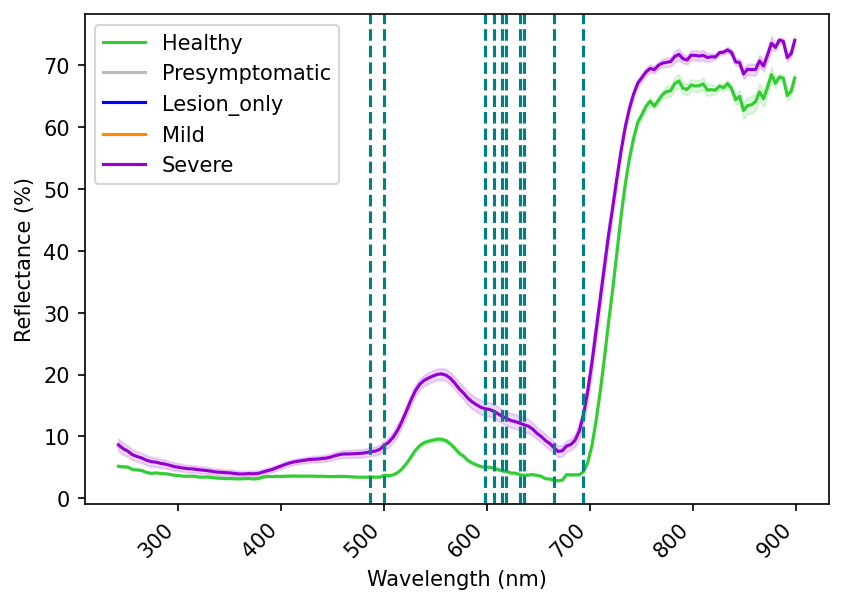

In [53]:
# top 10 selected wavelengths
selected_top_features = np.array(feature_ranking.nsmallest(10,'Ranking')['Wavelengths'])

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [54]:
# reduce X to the selected features
X_new = rfe_fit.transform(X)
X_new.shape

(175, 10)

In [55]:
# compare the classification accuracy using only selected wavelengths
models = get_models()
methods.append ('RFE_RF')
for name, model in models:
    scores = evaluate_model(model, X_new, y)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)


In [56]:
# For RFE model, all features should be included to get all their scores
# Or only number of n_features_to_select will have scores
rfe2 = RFE(estimator, n_features_to_select=1)
# fit RFE
tic = time()
rfe_fit2 = rfe2.fit(X, y)
toc = time()

# For RFE model, set the score for each feature equal to (total number of features - ranking of each feature)
rfe_fit2_scores = rfe_fit2.ranking_
for i in range(len(rfe_fit2_scores)):
    rfe_fit2_scores[i] = len(rfe_fit2_scores) - rfe_fit2_scores[i]

# build a dataframe including scores for each feature
dfscores = pd.DataFrame(rfe_fit2_scores)
dfcolumns = pd.DataFrame(X.columns)

# concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Wavelengths','Score']  #naming the dataframe columns

# sort the featureScores dataframe based on feature weight and ignore the original index
feature_sorted = featureScores.sort_values(by = 'Score', ascending=False, ignore_index=True)
# only save the top n features into the list
df_top_n_features = feature_sorted['Wavelengths'][0:top_n_features]
top_features.append(df_top_n_features.values)

In [57]:
# reduce X to the selected features WITH custom distance
X_dist = band_select_distance(X, featureScores, distance, top_n_features)
X_dist.shape
# save the top n features WITH custom distance into the list
top_features_dist.append(X_dist.columns)

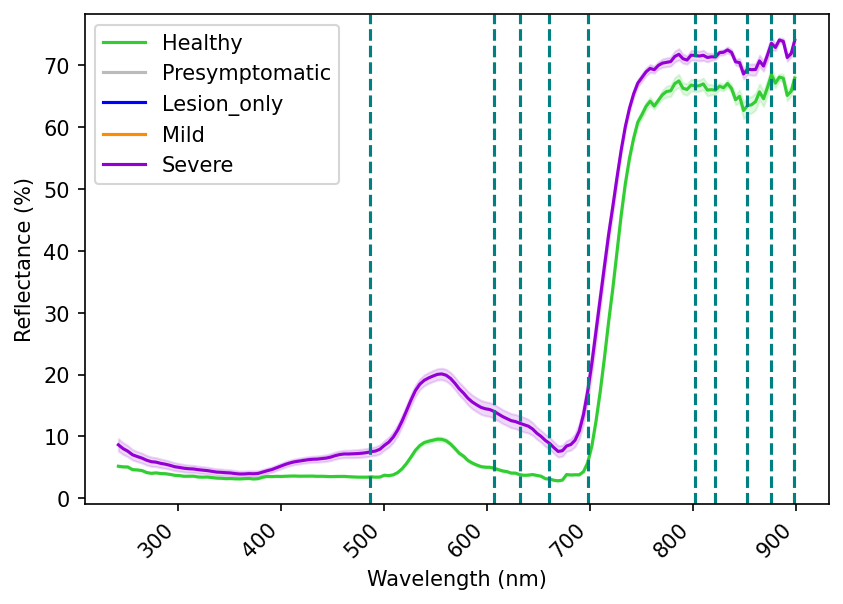

In [58]:
# set the wavelengths to be plotted
selected_top_features = X_dist.columns

# plot the selected wavelengths
i = 0
labels=['Healthy', 'Presymptomatic', 'Lesion_only','Mild','Severe']
color = ['#32CD32', '#BBBBBB', '#0000FF', '#FF8C00', '#9400D3'] # hex code
fig, ax = plt.subplots(dpi=150)
fig = plot_selected_wvs(selected_top_features) # call the plot_selected_wvs function
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance (%)')
plt.legend(loc='best')
plt.show()

In [59]:
# compare the classification accuracy using only selected wavelengths
models = get_models()
#methods.append ('RFE_RF')
for name, model in models:
    scores = evaluate_model(model, X_dist, y)
    results_dist.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))

>RF 100.000 (0.000)


## **6. Save the results**

In [60]:
# build a dataframe including distanced top n features for each feature selection methods
df_top_features_dist = pd.DataFrame(top_features_dist)
# transpose the dataframe
df_top_features_dist = df_top_features_dist.T
#naming the dataframe columns
df_top_features_dist.columns = methods[0:4]

# write the dataframe of cross validation accuracy to CVS file
df_top_features_dist.to_csv('/content/HyperspecFeatureSelection/results/peanut_ssr_top_features_distanced.csv', encoding='utf-8', header='true')
df_top_features_dist

,Chi2,SFM_RF,SFM_SVML,RFE_RF
0,702.233948,594.515015,899.225586,607.117432
1,594.515015,623.850769,853.435486,661.207214
2,615.494019,509.361176,830.06311,632.187378
3,573.411438,487.766541,689.979309,487.766541
4,636.348206,648.800354,644.654663,698.154175
5,526.549194,689.979309,623.850769,899.225586
6,552.184326,573.411438,590.30426,822.230164
7,657.07666,539.388794,517.964966,802.555725
8,505.052002,669.453186,665.332703,876.617249
9,722.556091,260.687927,810.441162,853.435486


## **References**

Data and scripts for the peanut stem rot study: https://github.com/LiLabAtVT/HyperspecFeatureSelection.git

Wei, X., Aguilera, M., Walcheck, R., Tholl, D., Li, S., Langston Jr, D. B., and Mehl, H. L. 2021. Detection of Soilborne Disease Utilizing Sensor Technologies: Lessons Learned from Studies on Stem Rot of Peanut. Plant Health Progress, 22(4), 436-444. DOI: [10.1094/PHP-03-21-0055-SYN](https://doi.org/10.1094/PHP-03-21-0055-SYN)

Wei, X., Johnson, M. A., Langston Jr, D. B., Mehl, H. L., and Li, S. 2021. Identifying optimal wavelengths as disease signatures using hyperspectral sensor and machine learning. Remote Sensing, 13(14), 2833. DOI: [10.3390/rs13142833](https://doi.org/10.3390/rs13142833)